 **C2 Beaconing Discovery via Periodicity and Behavioral Features in
Network Flow Logs**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget -O ctu13_s1_binetflow.csv \
  "https://mcfp.felk.cvut.cz/publicDatasets/CTU-Malware-Capture-Botnet-42/detailed-bidirectional-flow-labels/capture20110810.binetflow"
!ls -lh ctu13_s1_binetflow.csv


--2026-05-01 16:20:32--  https://mcfp.felk.cvut.cz/publicDatasets/CTU-Malware-Capture-Botnet-42/detailed-bidirectional-flow-labels/capture20110810.binetflow
Resolving mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)... 147.32.82.194
Connecting to mcfp.felk.cvut.cz (mcfp.felk.cvut.cz)|147.32.82.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 386629271 (369M)
Saving to: ‘ctu13_s1_binetflow.csv’

ctu13_s1_binetflow. 100%[===================>] 368.72M  4.25MB/s    in 85s     

2026-05-01 16:21:58 (4.31 MB/s) - ‘ctu13_s1_binetflow.csv’ saved [386629271/386629271]

-rw-r--r-- 1 root root 369M Jan 30  2015 ctu13_s1_binetflow.csv


Loading and normalizing columns

In [ ]:
import pandas as pd
import numpy as np

cols = [
    "StartTime","Dur","Proto","SrcAddr","Sport","Dir",
    "DstAddr","Dport","State","sTos","dTos",
    "TotPkts","TotBytes","SrcBytes","Label"
]

df = pd.read_csv("ctu13_s1_binetflow.csv", low_memory=False, nrows=2_000_000)

# If header missing, reload with known column names
if "StartTime" not in df.columns:
    df = pd.read_csv("ctu13_s1_binetflow.csv", header=None, names=cols, low_memory=False, nrows=2_000_000)

df["Label"] = df["Label"].astype(str)
df.head()


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label
0,2011/08/10 09:46:53.047277,3550.182373,udp,212.50.71.179,39678,<->,147.32.84.229,13363,CON,0.0,0.0,12,875,413,flow=Background-UDP-Established
1,2011/08/10 09:46:53.048843,0.000883,udp,84.13.246.132,28431,<->,147.32.84.229,13363,CON,0.0,0.0,2,135,75,flow=Background-UDP-Established
2,2011/08/10 09:46:53.049895,0.000326,tcp,217.163.21.35,80,<?>,147.32.86.194,2063,FA_A,0.0,0.0,2,120,60,flow=Background
3,2011/08/10 09:46:53.053771,0.056966,tcp,83.3.77.74,32882,<?>,147.32.85.5,21857,FA_FA,0.0,0.0,3,180,120,flow=Background
4,2011/08/10 09:46:53.053937,3427.768066,udp,74.89.223.204,21278,<->,147.32.84.229,13363,CON,0.0,0.0,42,2856,1596,flow=Background-UDP-Established


Creating STRICT labels and building balanced dataset



In [ ]:
# STRICT labeling based on CTU label guidance:
# - "From-Botnet" = malicious (beaconing/botnet activity)
# - "From-Normal" = normal
# Everything else = ignore (background/unknown) for cleaner ground truth
is_bot = df["Label"].str.startswith("From-Botnet")
is_norm = df["Label"].str.startswith("From-Normal")

bot_df = df[is_bot].copy()
norm_df = df[is_norm].copy()

print("Botnet rows:", len(bot_df))
print("Normal rows:", len(norm_df))

# Balance = take min count
n = min(len(bot_df), len(norm_df))
bot_df = bot_df.sample(n=n, random_state=42)
norm_df = norm_df.sample(n=n, random_state=42)

balanced = pd.concat([bot_df, norm_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
balanced["binary_label"] = np.where(balanced["Label"].str.startswith("From-Botnet"), 1, 0)

print("Balanced shape:", balanced.shape)
balanced["binary_label"].value_counts()


Botnet rows: 0
Normal rows: 0
Balanced shape: (0, 16)


,count
binary_label,


Converting to our project flow schema

In [ ]:
balanced["timestamp"] = pd.to_datetime(balanced["StartTime"], errors="coerce")
balanced["src_ip"] = balanced["SrcAddr"].astype(str)
balanced["dst_ip"] = balanced["DstAddr"].astype(str)
balanced["src_port"] = pd.to_numeric(balanced["Sport"], errors="coerce")
balanced["dst_port"] = pd.to_numeric(balanced["Dport"], errors="coerce")
balanced["protocol"] = balanced["Proto"].astype(str)

balanced["bytes"] = pd.to_numeric(balanced["TotBytes"], errors="coerce")
balanced["packets"] = pd.to_numeric(balanced["TotPkts"], errors="coerce")

flows = balanced[["timestamp","src_ip","dst_ip","src_port","dst_port","protocol","bytes","packets","binary_label"]].dropna()
flows = flows.sort_values("timestamp").reset_index(drop=True)

flows.head(), flows["binary_label"].value_counts()


(Empty DataFrame
 Columns: [timestamp, src_ip, dst_ip, src_port, dst_port, protocol, bytes, packets, binary_label]
 Index: [],
 Series([], Name: count, dtype: int64))

Real Dataset (CTU-13) — Pair-level Balanced

In [ ]:
import pandas as pd
import numpy as np

# after downloading CTU file as: ctu13_s1_binetflow.csv
cols = [
    "StartTime","Dur","Proto","SrcAddr","Sport","Dir",
    "DstAddr","Dport","State","sTos","dTos",
    "TotPkts","TotBytes","SrcBytes","Label"
]

df = pd.read_csv("ctu13_s1_binetflow.csv", low_memory=False, nrows=2_000_000)
if "StartTime" not in df.columns:
    df = pd.read_csv("ctu13_s1_binetflow.csv", header=None, names=cols, low_memory=False, nrows=2_000_000)

df["Label"] = df["Label"].astype(str)

df["timestamp"] = pd.to_datetime(df["StartTime"], errors="coerce")
df["src_ip"] = df["SrcAddr"].astype(str)
df["dst_ip"] = df["DstAddr"].astype(str)
df["src_port"] = pd.to_numeric(df["Sport"], errors="coerce")
df["dst_port"] = pd.to_numeric(df["Dport"], errors="coerce")
df["protocol"] = df["Proto"].astype(str)

df["bytes"] = pd.to_numeric(df["TotBytes"], errors="coerce")
df["packets"] = pd.to_numeric(df["TotPkts"], errors="coerce")

flows = df[["timestamp","src_ip","dst_ip","src_port","dst_port","protocol","bytes","packets","Label"]].dropna()
flows = flows.sort_values("timestamp").reset_index(drop=True)

print("Flows:", flows.shape)
flows.head()


Flows: (1969479, 9)


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes,packets,Label
0,2011-08-10 09:46:53.047277,212.50.71.179,147.32.84.229,39678.0,13363.0,udp,875,12,flow=Background-UDP-Established
1,2011-08-10 09:46:53.048843,84.13.246.132,147.32.84.229,28431.0,13363.0,udp,135,2,flow=Background-UDP-Established
2,2011-08-10 09:46:53.049895,217.163.21.35,147.32.86.194,80.0,2063.0,tcp,120,2,flow=Background
3,2011-08-10 09:46:53.053771,83.3.77.74,147.32.85.5,32882.0,21857.0,tcp,180,3,flow=Background
4,2011-08-10 09:46:53.053937,74.89.223.204,147.32.84.229,21278.0,13363.0,udp,2856,42,flow=Background-UDP-Established


checking how many pairs

In [ ]:
PAIR_COLS = ["src_ip","dst_ip","dst_port","protocol"]

print("Total flow rows:", len(flows))
print("Unique pairs in flows:", flows[PAIR_COLS].drop_duplicates().shape[0])
print("Label examples:", flows["Label"].astype(str).head(5).tolist())


Total flow rows: 1969479
Unique pairs in flows: 617101
Label examples: ['flow=Background-UDP-Established', 'flow=Background-UDP-Established', 'flow=Background', 'flow=Background', 'flow=Background-UDP-Established']


checking botnet vs non-botnet row counts

In [ ]:
lbl = flows["Label"].astype(str)

is_bot = lbl.str.contains("Botnet", case=False, na=False) | lbl.str.startswith("From-Botnet")
print("Botnet rows:", int(is_bot.sum()))
print("Non-botnet rows:", int((~is_bot).sum()))
print("Top label values:\n", lbl.value_counts().head(10))


Botnet rows: 29099
Non-botnet rows: 1940380
Top label values:
 Label
flow=Background-UDP-Established           811675
flow=To-Background-UDP-CVUT-DNS-Server    675017
flow=Background-TCP-Established           155256
flow=Background-Established-cmpgw-CVUT     92051
flow=Background-TCP-Attempt                90194
flow=Background-UDP-Attempt                47704
flow=From-Botnet-V42-UDP-DNS               19431
flow=Background-Attempt-cmpgw-CVUT         14483
flow=From-Normal-V42-Stribrek              12808
flow=To-Background-CVUT-Proxy              12221
Name: count, dtype: int64


Pair stats + pair labels

In [ ]:
import numpy as np
import pandas as pd

PAIR_COLS = ["src_ip", "dst_ip", "dst_port", "protocol"]

lbl = flows["Label"].astype(str)
is_bot = lbl.str.contains("Botnet", case=False, na=False) | lbl.str.startswith("From-Botnet")

work = flows.copy()
work["y_flow"] = np.where(is_bot, 1, 0)

pair_stats = (
    work.groupby(PAIR_COLS)
        .agg(flow_count=("y_flow", "size"),
             bot_ratio=("y_flow", "mean"))
        .reset_index()
)

# Pair label by majority of flows in the pair
pair_stats["y_pair"] = (pair_stats["bot_ratio"] >= 0.5).astype(int)

# Minimum flows per pair so inter-arrival features make sense
MIN_FLOWS_PER_PAIR = 10
pair_stats = pair_stats[pair_stats["flow_count"] >= MIN_FLOWS_PER_PAIR].copy()

print("Pairs after MIN_FLOWS_PER_PAIR:", len(pair_stats))
print("Pairs by class:\n", pair_stats["y_pair"].value_counts())
pair_stats.sort_values("flow_count", ascending=False).head(10)


Pairs after MIN_FLOWS_PER_PAIR: 8172
Pairs by class:
 y_pair
0    7830
1     342
Name: count, dtype: int64


,src_ip,dst_ip,dst_port,protocol,flow_count,bot_ratio,y_pair
79391,147.32.84.138,147.32.80.9,53.0,udp,379795,0.0,0
147532,147.32.84.59,147.32.80.9,53.0,udp,70687,0.0,0
175122,147.32.85.25,147.32.80.9,53.0,udp,30352,0.0,0
176754,147.32.85.34,147.32.80.9,53.0,udp,24612,0.0,0
189782,147.32.86.20,147.32.80.9,53.0,udp,10625,0.0,0
83375,147.32.84.170,147.32.80.9,53.0,udp,8635,0.0,0
85035,147.32.84.212,147.32.80.9,53.0,udp,7669,0.0,0
178209,147.32.85.7,147.32.80.9,53.0,udp,6141,0.0,0
192706,147.32.86.99,147.32.80.9,53.0,udp,5584,0.0,0
80024,147.32.84.165,147.32.80.9,53.0,udp,5482,1.0,1


Balance the pairs

In [ ]:
bot_pairs = pair_stats[pair_stats["y_pair"] == 1]
norm_pairs = pair_stats[pair_stats["y_pair"] == 0]

n = min(len(bot_pairs), len(norm_pairs))   # will be 342
print("Balancing to pairs per class:", n)

selected_pairs = pd.concat([
    bot_pairs.sample(n=n, random_state=42),
    norm_pairs.sample(n=n, random_state=42),
]).reset_index(drop=True)

print(selected_pairs["y_pair"].value_counts())


Balancing to pairs per class: 342
y_pair
1    342
0    342
Name: count, dtype: int64


Building the balanced flows dataset

In [ ]:
balanced_flows = work.merge(
    selected_pairs[PAIR_COLS + ["y_pair"]],
    on=PAIR_COLS,
    how="inner"
).sort_values("timestamp").reset_index(drop=True)

print("Balanced flows rows:", len(balanced_flows))
print("Balanced unique pairs:", balanced_flows[PAIR_COLS].drop_duplicates().shape[0])
balanced_flows.head()


Balanced flows rows: 51477
Balanced unique pairs: 684


,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes,packets,Label,y_flow,y_pair
0,2011-08-10 09:46:53.427249,147.32.86.20,87.98.230.229,4740.0,80.0,tcp,56870,63,flow=Background-TCP-Established,0,0
1,2011-08-10 09:46:54.239787,147.32.86.20,87.98.230.229,4741.0,80.0,tcp,60383,66,flow=Background-TCP-Established,0,0
2,2011-08-10 09:46:55.855924,109.236.84.83,147.32.85.100,53178.0,3126.0,tcp,186,3,flow=Background-TCP-Attempt,0,0
3,2011-08-10 09:46:58.511005,147.32.86.99,209.85.148.105,17225.0,443.0,tcp,2492,28,flow=Background-TCP-Established,0,0
4,2011-08-10 09:46:58.511188,147.32.86.99,209.85.148.105,17226.0,443.0,tcp,72544,243,flow=Background-TCP-Established,0,0


Feature engineering for beaconing and model training

In [ ]:
import numpy as np
import pandas as pd

def build_pair_features(flows_df):
    feats = []
    for (src, dst, dport, proto, y_pair), g in flows_df.groupby(PAIR_COLS + ["y_pair"]):
        g = g.sort_values("timestamp")
        if len(g) < 10:
            continue

        times = g["timestamp"].values.astype("datetime64[s]").astype("int64")
        diffs = np.diff(times)
        diffs = diffs[diffs > 0]
        if len(diffs) < 5:
            continue

        mean_iat = diffs.mean()
        std_iat = diffs.std()
        cv_iat = std_iat / mean_iat if mean_iat > 0 else np.nan

        med_iat = np.median(diffs)
        # fraction of gaps close to median (a periodicity proxy)
        near_median_frac = np.mean(np.abs(diffs - med_iat) <= max(1.0, 0.1 * med_iat))

        bytes_mean = g["bytes"].mean()
        bytes_std  = g["bytes"].std()
        bytes_cv   = bytes_std / bytes_mean if bytes_mean > 0 else np.nan

        pkts_mean = g["packets"].mean()
        pkts_std  = g["packets"].std()
        pkts_cv   = pkts_std / pkts_mean if pkts_mean > 0 else np.nan

        duration = (g["timestamp"].max() - g["timestamp"].min()).total_seconds()

        feats.append({
            "src_ip": src,
            "dst_ip": dst,
            "dst_port": dport,
            "protocol": proto,
            "flow_count": len(g),
            "duration_sec": duration,
            "mean_iat": mean_iat,
            "std_iat": std_iat,
            "cv_iat": cv_iat,
            "median_iat": med_iat,
            "near_median_frac": near_median_frac,
            "bytes_mean": bytes_mean,
            "bytes_cv": bytes_cv,
            "pkts_mean": pkts_mean,
            "pkts_cv": pkts_cv,
            "y_pair": int(y_pair),
        })

    return pd.DataFrame(feats)

features = build_pair_features(balanced_flows)
print("Feature rows (pairs):", features.shape)
print(features["y_pair"].value_counts())
features.head()


Feature rows (pairs): (629, 16)
y_pair
1    327
0    302
Name: count, dtype: int64


,src_ip,dst_ip,dst_port,protocol,flow_count,duration_sec,mean_iat,std_iat,cv_iat,median_iat,near_median_frac,bytes_mean,bytes_cv,pkts_mean,pkts_cv,y_pair
0,109.158.122.39,147.32.84.229,13363.0,udp,16,14720.963092,981.400000,168.112978,0.171299,1016.0,0.333333,135.000000,0.000000,2.000000,0.000000,0
1,109.165.49.56,147.32.84.229,13363.0,udp,20,5974.076572,314.421053,244.238088,0.776787,243.0,0.157895,573.750000,0.435990,2.700000,0.434921,0
2,109.166.143.67,147.32.84.229,13363.0,udp,17,11970.877820,748.187500,452.383993,0.604640,786.0,0.250000,325.588235,0.487500,4.823529,0.487500,0
3,109.236.141.150,147.32.84.229,13363.0,udp,10,14283.798232,1587.111111,385.986886,0.243201,1380.0,0.444444,197.700000,0.792583,2.400000,0.351364,0
4,109.236.84.83,147.32.85.100,3126.0,tcp,41,15201.273528,380.050000,124.213717,0.326835,446.0,0.750000,186.000000,0.000000,3.000000,0.000000,0


Training and Evaluating

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

feature_cols = [
    "flow_count","duration_sec","mean_iat","std_iat","cv_iat",
    "median_iat","near_median_frac","bytes_mean","bytes_cv","pkts_mean","pkts_cv"
]

X = features[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = features["y_pair"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_train_s, y_train)

pred = clf.predict(X_test_s)

print("Confusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nReport:\n", classification_report(y_test, pred, digits=4))


Confusion Matrix:
 [[66 10]
 [ 5 77]]

Report:
               precision    recall  f1-score   support

           0     0.9296    0.8684    0.8980        76
           1     0.8851    0.9390    0.9112        82

    accuracy                         0.9051       158
   macro avg     0.9073    0.9037    0.9046       158
weighted avg     0.9065    0.9051    0.9049       158



Training Random Forest and comparing to Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
import numpy as np
import pandas as pd

feature_cols = [
    "flow_count","duration_sec","mean_iat","std_iat","cv_iat",
    "median_iat","near_median_frac","bytes_mean","bytes_cv","pkts_mean","pkts_cv"
]

X = features[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = features["y_pair"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Logistic Regression (already did, but keep for comparison)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=3000)
logreg.fit(X_train_s, y_train)
pred_lr = logreg.predict(X_test_s)

# Random Forest (no scaling needed)
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("LogReg Confusion Matrix:\n", confusion_matrix(y_test, pred_lr))
print("\nRF Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))

LogReg Confusion Matrix:
 [[66 10]
 [ 5 77]]

RF Confusion Matrix:
 [[73  3]
 [ 4 78]]


Creating a clean model comparison table

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

def summarize(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision(botnet)": p,
        "recall(botnet)": r,
        "f1(botnet)": f1
    }

comparison = pd.DataFrame([
    summarize("Logistic Regression", y_test, pred_lr),
    summarize("Random Forest", y_test, pred_rf),
]).sort_values("f1(botnet)", ascending=False)

comparison

,model,accuracy,precision(botnet),recall(botnet),f1(botnet)
1,Random Forest,0.955696,0.962963,0.951220,0.957055
0,Logistic Regression,0.905063,0.885057,0.939024,0.911243


Generating “Top Suspicious Pairs” report

In [ ]:
# rank by probability from RF
features["rf_prob"] = rf.predict_proba(X)[:, 1]

def reason_text(row):
    r=[]
    if row["cv_iat"] < 0.25: r.append("very periodic timing (low CV)")
    elif row["cv_iat"] < 0.4: r.append("periodic timing (low CV)")
    if row["near_median_frac"] > 0.70: r.append("high interval consistency")
    if row["flow_count"] >= 50: r.append("many repeats")
    if 5 <= row["median_iat"] <= 300: r.append("beacon-like interval range")
    return "; ".join(r) if r else "—"

features["reason"] = features.apply(reason_text, axis=1)

top_report = features.sort_values("rf_prob", ascending=False).head(20)[
    ["src_ip","dst_ip","dst_port","protocol","rf_prob","cv_iat","near_median_frac","median_iat","flow_count","y_pair","reason"]
]
top_report

,src_ip,dst_ip,dst_port,protocol,rf_prob,cv_iat,near_median_frac,median_iat,flow_count,y_pair,reason
358,147.32.84.165,98.139.175.224,25.0,tcp,1.0,1.931582,0.125000,82.5,33,1,beacon-like interval range
357,147.32.84.165,98.137.54.238,25.0,tcp,1.0,1.902634,0.136364,172.5,23,1,beacon-like interval range
356,147.32.84.165,98.137.54.237,25.0,tcp,1.0,1.283209,0.058824,252.0,18,1,beacon-like interval range
354,147.32.84.165,95.167.166.125,53.0,udp,1.0,0.672280,0.142857,10.5,15,1,beacon-like interval range
343,147.32.84.165,92.38.229.222,53.0,udp,1.0,0.550117,0.411765,9.0,18,1,beacon-like interval range
352,147.32.84.165,94.245.120.86,25.0,tcp,1.0,1.426937,0.000000,145.0,15,1,beacon-like interval range
341,147.32.84.165,92.241.70.36,53.0,udp,1.0,0.591368,0.000000,11.0,13,1,beacon-like interval range
342,147.32.84.165,92.38.229.145,53.0,udp,1.0,0.955747,0.300000,8.0,11,1,beacon-like interval range
338,147.32.84.165,91.217.21.170,53.0,udp,1.0,1.250498,0.222222,244.0,10,1,beacon-like interval range
332,147.32.84.165,89.208.32.116,53.0,udp,1.0,0.660676,0.375000,9.0,17,1,beacon-like interval range


In [ ]:
top_report.to_csv("week7_top_suspicious_pairs.csv", index=False)
from google.colab import files
files.download("week7_top_suspicious_pairs.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Add 2 plots for the demo (usability + performance)

<Figure size 640x480 with 0 Axes>

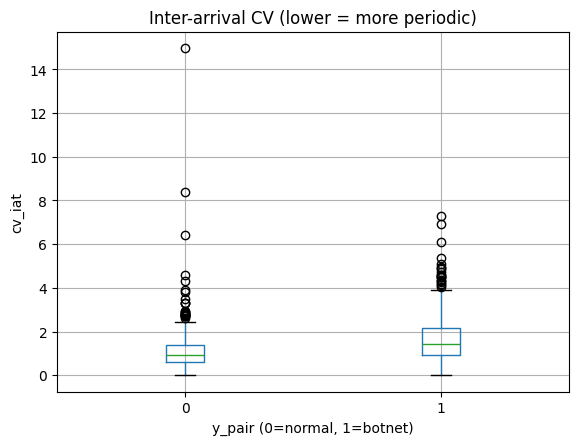

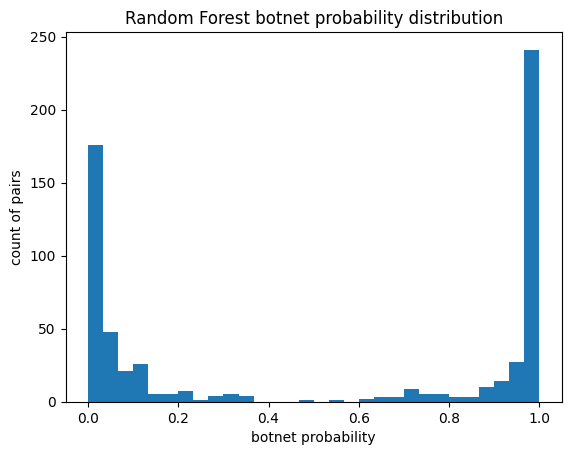

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
features.boxplot(column="cv_iat", by="y_pair")
plt.title("Inter-arrival CV (lower = more periodic)")
plt.suptitle("")
plt.xlabel("y_pair (0=normal, 1=botnet)")
plt.ylabel("cv_iat")
plt.show()

plt.figure()
plt.hist(features["rf_prob"], bins=30)
plt.title("Random Forest botnet probability distribution")
plt.xlabel("botnet probability")
plt.ylabel("count of pairs")
plt.show()

Week 8 testing

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def summarize(model_name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision(botnet)": p,
        "recall(botnet)": r,
        "f1(botnet)": f1,
        "TN_FP_FN_TP": confusion_matrix(y_true, y_pred).ravel().tolist()
    }

results = []

# --- Test Setup (same split for fair comparison) ---
X = features[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = features["y_pair"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- Logistic Regression baseline (Week 6 regression test) ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=3000)
logreg.fit(X_train_s, y_train)
pred_lr = logreg.predict(X_test_s)
results.append(summarize("LogisticRegression", y_test, pred_lr))

# --- Random Forest (Week 7 improvement validation) ---
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
results.append(summarize("RandomForest", y_test, pred_rf))

# --- Threshold sensitivity test (RF prob thresholds) ---
rf_prob = rf.predict_proba(X_test)[:, 1]
for thr in [0.3, 0.5, 0.7]:
    pred_thr = (rf_prob >= thr).astype(int)
    results.append(summarize(f"RF(threshold={thr})", y_test, pred_thr))

# --- Feature sanity checks ---
sanity = {
    "features_rows": int(len(features)),
    "nan_count_total": int(features[feature_cols].isna().sum().sum()),
    "inf_count_total": int(np.isinf(features[feature_cols].to_numpy()).sum()),
    "min_flow_count": int(features["flow_count"].min()),
    "median_iat_min": float(features["median_iat"].min()),
}
print("=== Feature sanity checks ===")
print(sanity)

df_results = pd.DataFrame(results).sort_values("f1(botnet)", ascending=False)
print("\n=== Week 8 Test Results (sorted by F1) ===")
display(df_results)

print("\n=== Pass/Fail quick checks ===")
# Example pass criteria
rf_row = df_results[df_results["model"]=="RandomForest"].iloc[0]
lr_row = df_results[df_results["model"]=="LogisticRegression"].iloc[0]
print("RF F1 - LR F1 =", float(rf_row["f1(botnet)"] - lr_row["f1(botnet)"]))
print("RF Recall(botnet) =", float(rf_row["recall(botnet)"]))

=== Feature sanity checks ===
{'features_rows': 629, 'nan_count_total': 0, 'inf_count_total': 0, 'min_flow_count': 10, 'median_iat_min': 1.0}

=== Week 8 Test Results (sorted by F1) ===


,model,accuracy,precision(botnet),recall(botnet),f1(botnet),TN_FP_FN_TP
1,RandomForest,0.955696,0.962963,0.951220,0.957055,"[73, 3, 4, 78]"
3,RF(threshold=0.5),0.955696,0.962963,0.951220,0.957055,"[73, 3, 4, 78]"
4,RF(threshold=0.7),0.943038,0.974026,0.914634,0.943396,"[74, 2, 7, 75]"
2,RF(threshold=0.3),0.930380,0.898876,0.975610,0.935673,"[67, 9, 2, 80]"
0,LogisticRegression,0.905063,0.885057,0.939024,0.911243,"[66, 10, 5, 77]"



=== Pass/Fail quick checks ===
RF F1 - LR F1 = 0.04581261117363056
RF Recall(botnet) = 0.9512195121951219


Set mode + DNS allowlist

In [ ]:
MODE = "balanced"  # "high_recall"=0.3, "balanced"=0.5, "low_fp"=0.7
THRESHOLDS = {"high_recall": 0.3, "balanced": 0.5, "low_fp": 0.7}
THR = THRESHOLDS[MODE]
print("Operating mode:", MODE, "| threshold:", THR)

# DNS-only allowlist (based on CTU top label: To-Background-UDP-CVUT-DNS-Server)
ALLOWLIST_DNS_SERVER_IPS = {"147.32.80.9"}   # your CTU DNS server
ALLOWLIST_DNS_PORT = 53

Operating mode: balanced | threshold: 0.5


Apply RF prediction + DNS allowlist

In [ ]:
import numpy as np

# ensure rf_prob exists
if "rf_prob" not in features.columns:
    X_all = features[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    features["rf_prob"] = rf.predict_proba(X_all)[:, 1]

# raw RF prediction
features["pred_rf"] = (features["rf_prob"] >= THR).astype(int)

# DNS allowlist: (dst_ip == DNS server) AND (dst_port == 53)
features["allowlisted"] = (features["dst_ip"].isin(ALLOWLIST_DNS_SERVER_IPS)) & (features["dst_port"] == ALLOWLIST_DNS_PORT)

# final decision: allowlisted pairs forced to normal (0)
features["final_pred"] = np.where(features["allowlisted"], 0, features["pred_rf"])

Add clear reason codes (includes allowlist)

In [ ]:
def reason_codes(row):
    codes = []
    if row["cv_iat"] < 0.25:
        codes.append("PERIODIC_VERY_LOW_CV")
    elif row["cv_iat"] < 0.40:
        codes.append("PERIODIC_LOW_CV")

    if row["near_median_frac"] > 0.70:
        codes.append("HIGH_INTERVAL_CONSISTENCY")
    elif row["near_median_frac"] > 0.55:
        codes.append("MED_INTERVAL_CONSISTENCY")

    if row["flow_count"] >= 50:
        codes.append("HIGH_REPEAT_COUNT")

    if 5 <= row["median_iat"] <= 300:
        codes.append("BEACON_CADENCE_RANGE")

    if row.get("allowlisted", False):
        codes.append("ALLOWLISTED_DNS_SERVER")

    return ",".join(codes) if codes else "ML_PATTERN"

features["reason_codes"] = features.apply(reason_codes, axis=1)

Week 9 evaluation (before vs after allowlist)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print("=== RF @ threshold (no allowlist) ===")
print(confusion_matrix(features["y_pair"], features["pred_rf"]))
print(classification_report(features["y_pair"], features["pred_rf"], digits=4))

print("\n=== RF @ threshold + DNS allowlist (final_pred) ===")
print(confusion_matrix(features["y_pair"], features["final_pred"]))
print(classification_report(features["y_pair"], features["final_pred"], digits=4))

=== RF @ threshold (no allowlist) ===
[[299   3]
 [  4 323]]
              precision    recall  f1-score   support

           0     0.9868    0.9901    0.9884       302
           1     0.9908    0.9878    0.9893       327

    accuracy                         0.9889       629
   macro avg     0.9888    0.9889    0.9889       629
weighted avg     0.9889    0.9889    0.9889       629


=== RF @ threshold + DNS allowlist (final_pred) ===
[[301   1]
 [  5 322]]
              precision    recall  f1-score   support

           0     0.9837    0.9967    0.9901       302
           1     0.9969    0.9847    0.9908       327

    accuracy                         0.9905       629
   macro avg     0.9903    0.9907    0.9905       629
weighted avg     0.9905    0.9905    0.9905       629



Export updated prototype report (Week 9 deliverable)

In [ ]:
import os
os.makedirs("outputs", exist_ok=True)

report_cols = [
    "src_ip","dst_ip","dst_port","protocol",
    "rf_prob","pred_rf","allowlisted","final_pred",
    "cv_iat","near_median_frac","median_iat","flow_count",
    "y_pair","reason_codes"
]

week9_report = features.sort_values("rf_prob", ascending=False)[report_cols]
week9_report.head(50).to_csv("outputs/week9_updated_prototype_report.csv", index=False)

print("Saved: outputs/week9_updated_prototype_report.csv")

Saved: outputs/week9_updated_prototype_report.csv


In [ ]:
import pandas as pd
df = pd.read_csv("outputs/week9_updated_prototype_report.csv")
df.head(20)   # show first 20 rows

,src_ip,dst_ip,dst_port,protocol,rf_prob,pred_rf,allowlisted,final_pred,cv_iat,near_median_frac,median_iat,flow_count,y_pair,reason_codes
0,147.32.84.165,98.139.175.224,25.0,tcp,1.0,1,False,1,1.931582,0.125000,82.5,33,1,BEACON_CADENCE_RANGE
1,147.32.84.165,98.137.54.238,25.0,tcp,1.0,1,False,1,1.902634,0.136364,172.5,23,1,BEACON_CADENCE_RANGE
2,147.32.84.165,98.137.54.237,25.0,tcp,1.0,1,False,1,1.283209,0.058824,252.0,18,1,BEACON_CADENCE_RANGE
3,147.32.84.165,95.167.166.125,53.0,udp,1.0,1,False,1,0.672280,0.142857,10.5,15,1,BEACON_CADENCE_RANGE
4,147.32.84.165,92.38.229.222,53.0,udp,1.0,1,False,1,0.550117,0.411765,9.0,18,1,BEACON_CADENCE_RANGE
5,147.32.84.165,94.245.120.86,25.0,tcp,1.0,1,False,1,1.426937,0.000000,145.0,15,1,BEACON_CADENCE_RANGE
6,147.32.84.165,92.241.70.36,53.0,udp,1.0,1,False,1,0.591368,0.000000,11.0,13,1,BEACON_CADENCE_RANGE
7,147.32.84.165,92.38.229.145,53.0,udp,1.0,1,False,1,0.955747,0.300000,8.0,11,1,BEACON_CADENCE_RANGE
8,147.32.84.165,91.217.21.170,53.0,udp,1.0,1,False,1,1.250498,0.222222,244.0,10,1,BEACON_CADENCE_RANGE
9,147.32.84.165,89.208.32.116,53.0,udp,1.0,1,False,1,0.660676,0.375000,9.0,17,1,BEACON_CADENCE_RANGE


In [ ]:
# Shows which common model variables exist right now
for name in ["rf","model","best_model","clf","random_forest","rf_model"]:
    print(name, "=>", name in globals())

rf => True
model => False
best_model => False
clf => True
random_forest => False
rf_model => False


In [ ]:
import pandas as pd

# list dataframes that exist
dfs = [(k, v.shape) for k, v in globals().items() if isinstance(v, pd.DataFrame)]
dfs[:20], len(dfs)

([('_', (20, 14)),
  ('__', (20, 11)),
  ('___', (2, 5)),
  ('df', (50, 14)),
  ('_7', (5, 15)),
  ('bot_df', (0, 15)),
  ('norm_df', (0, 15)),
  ('balanced', (0, 24)),
  ('flows', (1969479, 9)),
  ('_10', (5, 9)),
  ('work', (1969479, 10)),
  ('pair_stats', (8172, 7)),
  ('_13', (10, 7)),
  ('bot_pairs', (342, 7)),
  ('norm_pairs', (7830, 7)),
  ('selected_pairs', (684, 7)),
  ('balanced_flows', (51477, 11)),
  ('_15', (5, 11)),
  ('features', (629, 22)),
  ('_16', (5, 16))],
 43)

In [ ]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Your pair-level features dataframe
df_feat = features.copy()

# Columns to exclude from training
drop_cols = {
    "src_ip", "dst_ip", "dst_port", "protocol",
    "y_pair", "bot_ratio", "Label", "binary_label",
    "rf_prob", "pred_rf", "allowlisted", "final_pred",
    "reason_codes", "reason", "reasons", "Severity"
}

# Exact feature list used for training
feature_cols = [c for c in df_feat.columns if c not in drop_cols]

# Build X and y
X = df_feat[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_feat["y_pair"].astype(int)

print("Training features:")
print(feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
pred = rf.predict(X_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))
print("\nClassification Report:")
print(classification_report(y_test, pred, digits=4))

# Save model + exact feature column order together
bundle = {
    "model": rf,
    "feature_cols": feature_cols
}

joblib.dump(bundle, "c2_rf_model_bundle.joblib")
print("\nSaved: c2_rf_model_bundle.joblib")

Training features:
['flow_count', 'duration_sec', 'mean_iat', 'std_iat', 'cv_iat', 'median_iat', 'near_median_frac', 'bytes_mean', 'bytes_cv', 'pkts_mean', 'pkts_cv']
X shape: (629, 11)
y shape: (629,)
Confusion Matrix:
[[73  3]
 [ 4 78]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9481    0.9605    0.9542        76
           1     0.9630    0.9512    0.9571        82

    accuracy                         0.9557       158
   macro avg     0.9555    0.9559    0.9557       158
weighted avg     0.9558    0.9557    0.9557       158


Saved: c2_rf_model_bundle.joblib


In [ ]:
from google.colab import files
files.download("c2_rf_model_bundle.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip -q install gradio pandas numpy scikit-learn joblib

import gradio as gr
import pandas as pd
import numpy as np
import os
import joblib
from datetime import datetime


# =========================
# 1. Convert input CSV schema
# =========================

def to_standard_schema(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Timestamp
    if "timestamp" not in out.columns:
        if "StartTime" in out.columns:
            out["timestamp"] = out["StartTime"]
        else:
            raise ValueError("Missing timestamp column. Need `timestamp` or `StartTime`.")

    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")

    # Source IP
    if "src_ip" not in out.columns:
        if "SrcAddr" in out.columns:
            out["src_ip"] = out["SrcAddr"].astype(str)
        else:
            raise ValueError("Missing source IP column. Need `src_ip` or `SrcAddr`.")

    # Destination IP
    if "dst_ip" not in out.columns:
        if "DstAddr" in out.columns:
            out["dst_ip"] = out["DstAddr"].astype(str)
        else:
            raise ValueError("Missing destination IP column. Need `dst_ip` or `DstAddr`.")

    # Destination Port
    if "dst_port" not in out.columns:
        if "Dport" in out.columns:
            out["dst_port"] = pd.to_numeric(out["Dport"], errors="coerce")
        else:
            raise ValueError("Missing destination port column. Need `dst_port` or `Dport`.")

    out["dst_port"] = pd.to_numeric(out["dst_port"], errors="coerce")

    # Protocol
    if "protocol" not in out.columns:
        if "Proto" in out.columns:
            out["protocol"] = out["Proto"].astype(str)
        else:
            out["protocol"] = "tcp"

    out["protocol"] = out["protocol"].astype(str).str.lower()

    # Bytes
    if "bytes" not in out.columns:
        if "TotBytes" in out.columns:
            out["bytes"] = pd.to_numeric(out["TotBytes"], errors="coerce")
        else:
            out["bytes"] = 0

    # Packets
    if "packets" not in out.columns:
        if "TotPkts" in out.columns:
            out["packets"] = pd.to_numeric(out["TotPkts"], errors="coerce")
        else:
            out["packets"] = 0

    out["bytes"] = pd.to_numeric(out["bytes"], errors="coerce").fillna(0)
    out["packets"] = pd.to_numeric(out["packets"], errors="coerce").fillna(0)

    out = out.dropna(subset=["timestamp", "src_ip", "dst_ip", "dst_port", "protocol"])
    out = out.sort_values("timestamp").reset_index(drop=True)

    return out[[
        "timestamp",
        "src_ip",
        "dst_ip",
        "dst_port",
        "protocol",
        "bytes",
        "packets"
    ]]


# =========================
# 2. Build pair-level features
# =========================

PAIR_COLS = ["src_ip", "dst_ip", "dst_port", "protocol"]

def build_pair_features(flows: pd.DataFrame, min_flows_per_pair: int = 10) -> pd.DataFrame:
    rows = []

    for key, g in flows.groupby(PAIR_COLS):
        g = g.sort_values("timestamp")

        if len(g) < min_flows_per_pair:
            continue

        t = g["timestamp"].values.astype("datetime64[s]").astype("int64")
        iat = np.diff(t)
        iat = iat[iat > 0]

        if len(iat) < 5:
            continue

        mean_iat = float(np.mean(iat))
        std_iat = float(np.std(iat))
        cv_iat = float(std_iat / mean_iat) if mean_iat > 0 else np.nan
        median_iat = float(np.median(iat))

        near_median_frac = float(
            np.mean(np.abs(iat - median_iat) <= max(1.0, 0.10 * median_iat))
        )

        duration_sec = float(
            (g["timestamp"].max() - g["timestamp"].min()).total_seconds()
        )

        flow_count = int(len(g))

        bytes_mean = float(g["bytes"].mean())
        bytes_std = float(g["bytes"].std())
        bytes_cv = float(bytes_std / bytes_mean) if bytes_mean > 0 else np.nan

        pkts_mean = float(g["packets"].mean())
        pkts_std = float(g["packets"].std())
        pkts_cv = float(pkts_std / pkts_mean) if pkts_mean > 0 else np.nan

        src_ip, dst_ip, dst_port, proto = key

        rows.append({
            "src_ip": src_ip,
            "dst_ip": dst_ip,
            "dst_port": int(dst_port),
            "protocol": proto,
            "flow_count": flow_count,
            "duration_sec": duration_sec,
            "mean_iat": mean_iat,
            "std_iat": std_iat,
            "cv_iat": cv_iat,
            "median_iat": median_iat,
            "near_median_frac": near_median_frac,
            "bytes_mean": bytes_mean,
            "bytes_cv": bytes_cv,
            "pkts_mean": pkts_mean,
            "pkts_cv": pkts_cv,
        })

    return pd.DataFrame(rows)


# =========================
# 3. Reason codes and severity
# =========================

def build_reasons(row):
    reasons = []

    if row["cv_iat"] < 0.25:
        reasons.append("Very regular timing")
    elif row["cv_iat"] < 0.40:
        reasons.append("Regular timing")

    if row["near_median_frac"] > 0.70:
        reasons.append("Intervals repeat very consistently")
    elif row["near_median_frac"] > 0.55:
        reasons.append("Intervals are fairly consistent")

    if row["flow_count"] >= 50:
        reasons.append("Many repeated connections")

    if 5 <= row["median_iat"] <= 300:
        reasons.append("Typical beacon interval range")

    if row.get("allowlisted", False):
        reasons.append("Known DNS server traffic suppressed")

    if not reasons:
        reasons.append("Flagged by model-based multi-feature pattern")

    return " | ".join(reasons)


def severity_from_prob(p: float) -> str:
    if p >= 0.90:
        return "Critical"
    elif p >= 0.70:
        return "High"
    elif p >= 0.50:
        return "Medium"
    else:
        return "Low"


def severity_badge_html(sev: str) -> str:
    cls = str(sev).lower()
    return f'<span class="sev sev-{cls}">{sev}</span>'


# =========================
# 4. HTML output helpers
# =========================

def df_to_html(df: pd.DataFrame, title: str, max_rows: int = 50) -> str:
    if df is None or df.empty:
        return f"""
        <div class="card">
            <div class="card-title">{title}</div>
            <div class="muted">No results found.</div>
        </div>
        """

    view = df.head(max_rows).copy()

    for c in view.columns:
        if pd.api.types.is_float_dtype(view[c]):
            view[c] = view[c].map(lambda x: f"{x:.3f}" if pd.notnull(x) else "")

    if "Severity" in view.columns:
        view["Severity"] = view["Severity"].apply(severity_badge_html)

    html = view.to_html(index=False, escape=False)

    return f"""
    <div class="card">
        <div class="card-title">{title}</div>
        <div class="table-wrap">{html}</div>
        <div class="muted">Showing {min(len(view), max_rows)} of {len(df)} rows</div>
    </div>
    """


def summary_html(text: str) -> str:
    safe_text = str(text).replace("\n", "<br>")
    return f"""
    <div class="card">
        <div class="card-title">Summary</div>
        <div class="summary">{safe_text}</div>
    </div>
    """


# =========================
# 5. Final fixed light-theme CSS
# =========================

css = """
:root{
  --page-bg:#f1f5f9;
  --card-bg:#ffffff;
  --soft-bg:#f8fafc;
  --border:#cbd5e1;
  --text:#0f172a;
  --text-soft:#334155;
  --muted:#64748b;
  --accent:#2563eb;
  --accent-dark:#1d4ed8;
}

/* Whole dashboard */
body,
.gradio-container{
  background:var(--page-bg)!important;
  color:var(--text)!important;
  font-family:Inter, Arial, sans-serif!important;
}

/* Main container */
.gradio-container{
  max-width:1400px!important;
}

/* Important text */
.gradio-container h1,
.gradio-container h2,
.gradio-container h3,
.gradio-container h4,
.gradio-container p,
.gradio-container label,
.gradio-container .label-wrap,
.gradio-container .label-wrap span{
  color:#0f172a!important;
}

/* Title banner */
#titlebox{
  background:linear-gradient(135deg,#dbeafe,#f5f3ff);
  border:1px solid var(--border);
  border-radius:20px;
  padding:24px;
  margin-bottom:20px;
  box-shadow:0 10px 25px rgba(15,23,42,0.08);
}

#titlebox h1{
  color:#020617!important;
  font-size:34px!important;
  font-weight:900!important;
  margin-top:12px!important;
  margin-bottom:0!important;
}

/* Top badges */
.badge{
  display:inline-block;
  background:#ffffff!important;
  color:#0f172a!important;
  border:1px solid #cbd5e1!important;
  border-radius:999px!important;
  padding:7px 14px!important;
  margin-right:8px!important;
  font-size:12px!important;
  font-weight:800!important;
}

/* Gradio blocks and boxes */
.gradio-container .block,
.gradio-container .form,
.gradio-container .panel,
.gradio-container .wrap,
.gradio-container .contain,
.gradio-container .gr-box{
  background:#ffffff!important;
  color:#0f172a!important;
  border-color:#cbd5e1!important;
  border-radius:14px!important;
}

/* Input fields */
.gradio-container input,
.gradio-container textarea,
.gradio-container select{
  background:#ffffff!important;
  color:#0f172a!important;
  border:1px solid #cbd5e1!important;
  border-radius:10px!important;
}

.gradio-container input::placeholder,
.gradio-container textarea::placeholder{
  color:#64748b!important;
}

/* File upload area */
.gradio-container [data-testid="file-upload"],
.gradio-container [data-testid="file-upload"] *,
.gr-file,
.gr-file *{
  background:#ffffff!important;
  color:#0f172a!important;
  border-color:#cbd5e1!important;
}

.gr-file .wrap,
.gr-file .file-preview,
.gr-file .file-dropzone,
.gr-file .upload-container{
  background:#f8fafc!important;
  color:#0f172a!important;
  border:1px dashed #94a3b8!important;
  border-radius:14px!important;
}

/* File icons */
.gr-file svg{
  color:#2563eb!important;
  stroke:#2563eb!important;
}

/* Sliders */
input[type="range"]{
  accent-color:#2563eb!important;
}

.gr-slider,
.gr-slider *{
  color:#0f172a!important;
}

/* Checkbox */
.gr-checkbox,
.gr-checkbox label,
.gr-checkbox span{
  color:#0f172a!important;
}

/* Primary button */
button.primary,
.gr-button-primary{
  background:#2563eb!important;
  color:#ffffff!important;
  font-weight:900!important;
  border:none!important;
  border-radius:12px!important;
  padding:10px 16px!important;
}

button.primary *,
.gr-button-primary *{
  color:#ffffff!important;
}

button.primary:hover,
.gr-button-primary:hover{
  background:#1d4ed8!important;
}

/* General buttons */
button{
  border-radius:10px!important;
  font-weight:700!important;
}

/* Cards */
.card{
  background:#ffffff!important;
  border:1px solid #cbd5e1!important;
  border-radius:18px!important;
  padding:18px!important;
  margin-top:12px!important;
  box-shadow:0 8px 20px rgba(15,23,42,0.06)!important;
}

.card-title{
  color:#020617!important;
  font-size:16px!important;
  font-weight:900!important;
  margin-bottom:12px!important;
}

.summary{
  color:#0f172a!important;
  font-size:14px!important;
  line-height:1.7!important;
}

.muted{
  color:#64748b!important;
  font-size:12px!important;
  margin-top:10px!important;
}

/* Tabs */
.gradio-container .tabs,
.gradio-container .tab-nav{
  background:#ffffff!important;
  color:#0f172a!important;
  border-color:#cbd5e1!important;
}

.gradio-container button[role="tab"]{
  background:#ffffff!important;
  color:#475569!important;
  font-weight:800!important;
  border-radius:10px 10px 0 0!important;
}

.gradio-container button[role="tab"][aria-selected="true"]{
  background:#eff6ff!important;
  color:#0f172a!important;
  border-bottom:3px solid #2563eb!important;
}

/* Tables */
.table-wrap{
  overflow-x:auto!important;
}

table{
  width:100%!important;
  border-collapse:collapse!important;
  background:#ffffff!important;
  color:#0f172a!important;
  border:1px solid #cbd5e1!important;
  border-radius:14px!important;
  overflow:hidden!important;
}

thead th{
  background:#dbeafe!important;
  color:#020617!important;
  font-weight:900!important;
  padding:12px!important;
  border-bottom:1px solid #cbd5e1!important;
  white-space:nowrap!important;
}

tbody td{
  color:#0f172a!important;
  padding:11px 12px!important;
  border-bottom:1px solid #e2e8f0!important;
  vertical-align:top!important;
}

tbody tr:nth-child(odd) td{
  background:#f8fafc!important;
}

tbody tr:nth-child(even) td{
  background:#ffffff!important;
}

tbody tr:hover td{
  background:#e0f2fe!important;
}

/* Download output */
.gradio-container [data-testid="file-download"],
.gradio-container [data-testid="file-download"] *,
.gradio-container .download,
.gradio-container .download *{
  background:#ffffff!important;
  color:#0f172a!important;
  border-color:#cbd5e1!important;
}

/* Severity badges */
.sev{
  display:inline-block!important;
  padding:5px 11px!important;
  border-radius:999px!important;
  font-weight:900!important;
  font-size:12px!important;
  border:1px solid transparent!important;
  white-space:nowrap!important;
}

.sev-critical{
  background:#fee2e2!important;
  color:#991b1b!important;
  border-color:#fecaca!important;
}

.sev-high{
  background:#ffedd5!important;
  color:#9a3412!important;
  border-color:#fed7aa!important;
}

.sev-medium{
  background:#dbeafe!important;
  color:#1e40af!important;
  border-color:#bfdbfe!important;
}

.sev-low{
  background:#dcfce7!important;
  color:#166534!important;
  border-color:#bbf7d0!important;
}
"""


# =========================
# 6. Detection function
# =========================

def run_detection(flow_file, model_bundle_file, threshold, min_flows, dns_allowlist, dns_ip):
    try:
        if flow_file is None:
            return (
                summary_html("Please upload a flow CSV file to begin detection."),
                "",
                "",
                None
            )

        if model_bundle_file is None:
            return (
                summary_html("Please upload your trained model bundle file: c2_rf_model_bundle.joblib"),
                "",
                "",
                None
            )

        # Load model bundle
        bundle = joblib.load(model_bundle_file.name)

        if not isinstance(bundle, dict):
            return (
                summary_html("Model bundle error: uploaded file is not a valid dictionary bundle."),
                "",
                "",
                None
            )

        if "model" not in bundle:
            return (
                summary_html("Model bundle error: missing key `model`. Your joblib file must contain bundle['model']."),
                "",
                "",
                None
            )

        if "feature_cols" not in bundle:
            return (
                summary_html("Model bundle error: missing key `feature_cols`. Your joblib file must contain bundle['feature_cols']."),
                "",
                "",
                None
            )

        model = bundle["model"]
        feature_cols = bundle["feature_cols"]

        # Read uploaded traffic file
        df = pd.read_csv(flow_file.name)

        # Standardize schema
        flows = to_standard_schema(df)

        # Build pair-level features
        feats = build_pair_features(
            flows,
            min_flows_per_pair=int(min_flows)
        )

        if feats.empty:
            return (
                summary_html(
                    "No eligible communication pairs were found. "
                    "Try lowering MIN_FLOWS_PER_PAIR or upload a CSV with more repeated traffic."
                ),
                "",
                "",
                None
            )

        # DNS allowlist
        feats["allowlisted"] = False

        if dns_allowlist:
            feats["allowlisted"] = (
                (feats["dst_ip"].astype(str) == str(dns_ip)) &
                (feats["dst_port"].astype(int) == 53)
            )

        # Prepare model input
        X = (
            feats
            .reindex(columns=feature_cols, fill_value=0)
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        # Predict probability
        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X)[:, 1]
        else:
            preds = model.predict(X)
            probs = np.array(preds, dtype=float)

        feats["rf_prob"] = probs
        feats["pred_raw"] = (feats["rf_prob"] >= float(threshold)).astype(int)

        # Suppress allowlisted DNS
        feats["final_pred"] = np.where(
            feats["allowlisted"],
            0,
            feats["pred_raw"]
        )

        feats["Severity"] = feats["rf_prob"].apply(severity_from_prob)
        feats["Reasons"] = feats.apply(build_reasons, axis=1)

        cols_out = [
            "Severity",
            "src_ip",
            "dst_ip",
            "dst_port",
            "protocol",
            "rf_prob",
            "pred_raw",
            "allowlisted",
            "final_pred",
            "flow_count",
            "median_iat",
            "cv_iat",
            "near_median_frac",
            "Reasons"
        ]

        flagged = feats[feats["final_pred"] == 1].sort_values(
            "rf_prob",
            ascending=False
        )

        overall = feats.sort_values(
            "rf_prob",
            ascending=False
        )

        # Create output CSV
        os.makedirs("outputs", exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        out_path = f"outputs/flagged_pairs_{ts}.csv"

        flagged[cols_out].to_csv(out_path, index=False)

        # Severity counts
        severity_counts = flagged["Severity"].value_counts().to_dict()

        critical_count = severity_counts.get("Critical", 0)
        high_count = severity_counts.get("High", 0)
        medium_count = severity_counts.get("Medium", 0)
        low_count = severity_counts.get("Low", 0)

        summary = (
            f"Input rows loaded: {len(df)}\n"
            f"Standardized flow rows: {len(flows)}\n"
            f"Communication pairs extracted: {len(feats)}\n"
            f"Flagged beaconing pairs: {len(flagged)}\n"
            f"Detection threshold: {threshold}\n"
            f"Minimum flows per pair: {int(min_flows)}\n"
            f"Allowlisted DNS pairs suppressed: {int(feats['allowlisted'].sum())}\n\n"
            f"Severity breakdown:\n"
            f"Critical: {critical_count}\n"
            f"High: {high_count}\n"
            f"Medium: {medium_count}\n"
            f"Low: {low_count}\n\n"
            f"Flagged results CSV is ready to download."
        )

        return (
            summary_html(summary),
            df_to_html(flagged[cols_out], "Top Flagged Beaconing Pairs", 50),
            df_to_html(overall[cols_out], "Top Pairs Overall by RF Probability", 50),
            out_path
        )

    except Exception as e:
        error_msg = (
            f"Error: {type(e).__name__}: {e}\n\n"
            f"Check that your CSV has the required columns and that your model bundle contains "
            f"`model` and `feature_cols`."
        )

        return (
            summary_html(error_msg),
            "",
            "",
            None
        )


# =========================
# 7. Gradio Dashboard Layout
# =========================

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        neutral_hue="slate"
    ),
    css=css,
    title="C2 Beaconing Dashboard"
) as demo:

    gr.HTML("""
    <div id="titlebox">
      <div>
        <span class="badge">Pair-level Detection</span>
        <span class="badge">Reason Codes</span>
        <span class="badge">Severity Scoring</span>
        <span class="badge">CSV Export</span>
      </div>
      <h1>C2 Beaconing Dashboard</h1>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1, min_width=330):
            gr.Markdown("### Upload Files")

            flow_file = gr.File(
                label="Upload Flow CSV",
                file_types=[".csv"]
            )

            model_bundle_file = gr.File(
                label="Upload Model Bundle",
                file_types=[".joblib", ".pkl"]
            )

            gr.Markdown("### Detection Settings")

            threshold = gr.Slider(
                minimum=0,
                maximum=1,
                value=0.5,
                step=0.01,
                label="Detection Threshold"
            )

            min_flows = gr.Slider(
                minimum=3,
                maximum=50,
                value=10,
                step=1,
                label="Minimum Flows Per Pair"
            )

            dns_allowlist = gr.Checkbox(
                value=True,
                label="Enable DNS Allowlist"
            )

            dns_ip = gr.Textbox(
                value="147.32.80.9",
                label="DNS Server IP"
            )

            run_btn = gr.Button(
                "Run Detection",
                variant="primary"
            )

            download_out = gr.File(
                label="Download Flagged Results CSV"
            )

        with gr.Column(scale=2):
            summary_out = gr.HTML()

            with gr.Tabs():
                with gr.Tab("Top Flagged Pairs"):
                    flagged_out = gr.HTML()

                with gr.Tab("Top Pairs Overall"):
                    overall_out = gr.HTML()

    run_btn.click(
        fn=run_detection,
        inputs=[
            flow_file,
            model_bundle_file,
            threshold,
            min_flows,
            dns_allowlist,
            dns_ip
        ],
        outputs=[
            summary_out,
            flagged_out,
            overall_out,
            download_out
        ]
    )


demo.launch(share=True)

/tmp/ipykernel_1895/2168177043.py:756: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_1895/2168177043.py:756: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f7fbef3064f853dcb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
